In [ ]:
#import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
#use the same dataset

df = pd.read_csv(
"global_pharmacy_sales_2020_2025_daily_dataset.csv"
)

df.head()

,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag
0,2025-10-12,2025,10,12,Middle East,UAE,Chronic,Amlodipine,0-12,328,45.38,4774,466,0
1,2020-09-15,2020,9,15,South Asia,India,Chronic,Amlodipine,26-45,371,75.49,4584,181,1
2,2020-02-26,2020,2,26,Middle East,UAE,Vitamin,Vitamin C,0-12,948,22.51,3934,556,1
3,2025-11-09,2025,11,9,South Asia,Sri Lanka,Chronic,Amlodipine,0-12,275,63.29,4544,330,0
4,2022-04-04,2022,4,4,South America,Argentina,Chronic,Amlodipine,26-45,563,44.28,4284,590,0


In [ ]:
#check

df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177990 entries, 0 to 177989
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   date                   177990 non-null  object 
 1   year                   177990 non-null  int64  
 2   month                  177990 non-null  int64  
 3   day                    177990 non-null  int64  
 4   region                 177990 non-null  object 
 5   country                177990 non-null  object 
 6   category               177990 non-null  object 
 7   medicine               177990 non-null  object 
 8   age_group              177990 non-null  object 
 9   units_sold             177990 non-null  int64  
 10  unit_price             177990 non-null  float64
 11  stock_level            177990 non-null  int64  
 12  expiry_days_remaining  177990 non-null  int64  
 13  covid_flag             177990 non-null  int64  
dtypes: float64(1), int64(7), object(6)
m

In [ ]:
#Create stock ratio

df['stock_ratio'] = (
    df['stock_level'] /
    df['units_sold']
)

In [ ]:
#Create Lables

def create_stock_label(x):

    if x < 5:
        return 0       # Reorder

    elif x < 15:
        return 1       # Sufficient

    else:
        return 2       # Overstock


df['stock_status'] = df['stock_ratio'].apply(
    create_stock_label
)

In [ ]:
#Check

df['stock_status'].value_counts()

,count
stock_status,
1,14915
2,7910
0,1316


In [ ]:
#Encode Text Clumns
#ANN cannot understand text
#Convert medicine,category to numbers

from sklearn.preprocessing import LabelEncoder


le_medicine = LabelEncoder()
le_category = LabelEncoder()


df['medicine_enc'] = le_medicine.fit_transform(
    df['medicine']
)


df['category_enc'] = le_category.fit_transform(
    df['category']
)

In [11]:
#Check

df.head()

,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag,stock_ratio,stock_status,medicine_enc,category_enc
0,2025-10-12,2025,10,12,Middle East,UAE,Chronic,Amlodipine,0-12,328.0,45.38,4774.0,466.0,0.0,14.554878,1,0,2
1,2020-09-15,2020,9,15,South Asia,India,Chronic,Amlodipine,26-45,371.0,75.49,4584.0,181.0,1.0,12.355795,1,0,2
2,2020-02-26,2020,2,26,Middle East,UAE,Vitamin,Vitamin C,0-12,948.0,22.51,3934.0,556.0,1.0,4.149789,0,10,4
3,2025-11-09,2025,11,9,South Asia,Sri Lanka,Chronic,Amlodipine,0-12,275.0,63.29,4544.0,330.0,0.0,16.523636,2,0,2
4,2022-04-04,2022,4,4,South America,Argentina,Chronic,Amlodipine,26-45,563.0,44.28,4284.0,590.0,0.0,7.609236,1,0,2


In [12]:
#Select Features

features = [

'units_sold',
'stock_level',
'unit_price',
'expiry_days_remaining',
'month',
'covid_flag',
'medicine_enc',
'category_enc'

]

In [13]:
#Create X and Y

X = df[features]

y = df['stock_status']

In [14]:
#Train/Test

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [15]:
#ckeck

X_train.shape
X_test.shape

(4829, 8)

In [16]:
#scaling

scaler = StandardScaler()


X_train = scaler.fit_transform(
    X_train
)


X_test = scaler.transform(
    X_test
)

In [17]:
#Build ANN Model

model = Sequential([

    Dense(
        64,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    Dropout(0.2),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        3,
        activation='softmax'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
#Compile

model.compile(

optimizer='adam',

loss='sparse_categorical_crossentropy',

metrics=['accuracy']

)

In [19]:
#check

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,755 (10.76 KB)

 Trainable params: 2,755 (10.76 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#Train

history = model.fit(

    X_train,
    y_train,

    epochs=30,

    batch_size=32,

    validation_split=0.2

)

Epoch 1/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8423 - loss: 0.3811 - val_accuracy: 0.9298 - val_loss: 0.1719
Epoch 2/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9265 - loss: 0.1691 - val_accuracy: 0.9676 - val_loss: 0.1013
Epoch 3/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9524 - loss: 0.1108 - val_accuracy: 0.9829 - val_loss: 0.0661
Epoch 4/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9638 - loss: 0.0874 - val_accuracy: 0.9837 - val_loss: 0.0576
Epoch 5/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9720 - loss: 0.0661 - val_accuracy: 0.9840 - val_loss: 0.0487
Epoch 6/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9774 - loss: 0.0560 - val_accuracy: 0.9863 - val_loss: 0.0411
Epoch 7/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9795 - loss: 0.0481 - val_accuracy: 0.9899 - val_loss: 0.0329
Epoch 8/30
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9842 - loss: 0.0405 - val_accuracy: 0.

In [21]:
#Evaluate
#Predict

pred = model.predict(X_test)

pred_class = pred.argmax(axis=1)

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [22]:
#Report

print(
classification_report(
    y_test,
    pred_class
)
)

              precision    recall  f1-score   support

           0       1.00      0.93      0.96       295
           1       0.99      0.99      0.99      2940
           2       0.99      1.00      0.99      1594

    accuracy                           0.99      4829
   macro avg       0.99      0.97      0.98      4829
weighted avg       0.99      0.99      0.99      4829



In [23]:
#Confusion Matrix

cm = confusion_matrix(
    y_test,
    pred_class
)

print(cm)

[[ 274   21    0]
 [   0 2918   22]
 [   1    6 1587]]


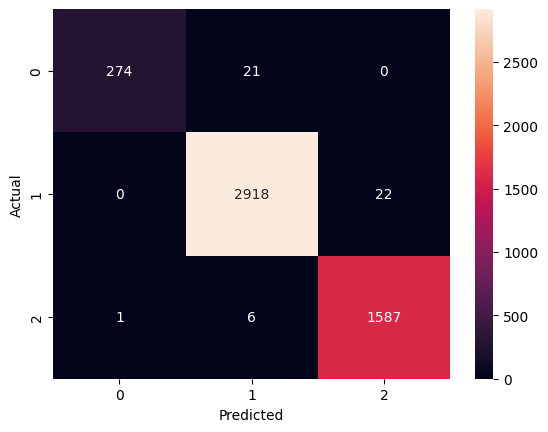

In [24]:
#plot

import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
#save model

model.save(
"stock_classifier.keras"
)

In [34]:
import pickle

pickle.dump(
    scaler,
    open("stock_scaler.pkl","wb")
)

In [36]:
import os

os.makedirs("models", exist_ok=True)

model.save(
    "models/stock_classifier.keras"
)

In [37]:
import os

print(os.listdir("models"))

['stock_classifier.keras']


In [39]:
from google.colab import files

files.download("models/stock_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
import os
import shutil

os.makedirs("models", exist_ok=True)

shutil.move(
    "stock_scaler.pkl",
    "models/stock_scaler.pkl"
)

'models/stock_scaler.pkl'

In [43]:
import os
print(os.listdir("models"))

['stock_scaler.pkl', 'stock_classifier.keras']


In [44]:
from google.colab import files

files.download("models/stock_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
from tensorflow.keras.models import load_model

test_model = load_model(
    "models/stock_classifier.keras"
)

print("Model loaded successfully")

Model loaded successfully


In [46]:
import os

print(os.listdir("models"))

['stock_scaler.pkl', 'stock_classifier.keras']


In [47]:
prediction = test_model.predict(X_test[:1])

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
[[1.5418376e-06 9.9999845e-01 2.9852437e-08]]
